## Exercise 08 : Seaborn

In [18]:
import pandas as pd 
import sqlite3 
import matplotlib.pyplot as plt 
import seaborn as sns

### Make a connection to the database

In [19]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

### Run query including only project1

In [20]:
query = """
SELECT uid, timestamp, numTrials
FROM checker
WHERE
    uid LIKE 'user_%'
    -- uid IN ('user_2', 'user_4') 
    AND labname = 'project1'
    AND status = 'ready'
ORDER BY uid;
"""
df = pd.read_sql(sql=query, con=conn, parse_dates='timestamp')
df

,uid,timestamp,numTrials
0,user_1,2020-05-14 20:56:08.898880,1
1,user_1,2020-05-14 20:58:02.313690,2
2,user_1,2020-05-14 20:58:46.322457,3
3,user_1,2020-05-14 21:08:15.434237,4
4,user_1,2020-05-14 21:10:14.867603,5
...,...,...,...
946,user_8,2020-05-14 16:18:00.528528,4
947,user_8,2020-05-14 16:41:03.916147,5
948,user_8,2020-05-14 17:40:47.781946,6
949,user_8,2020-05-14 17:46:54.469822,7


### Create the graph

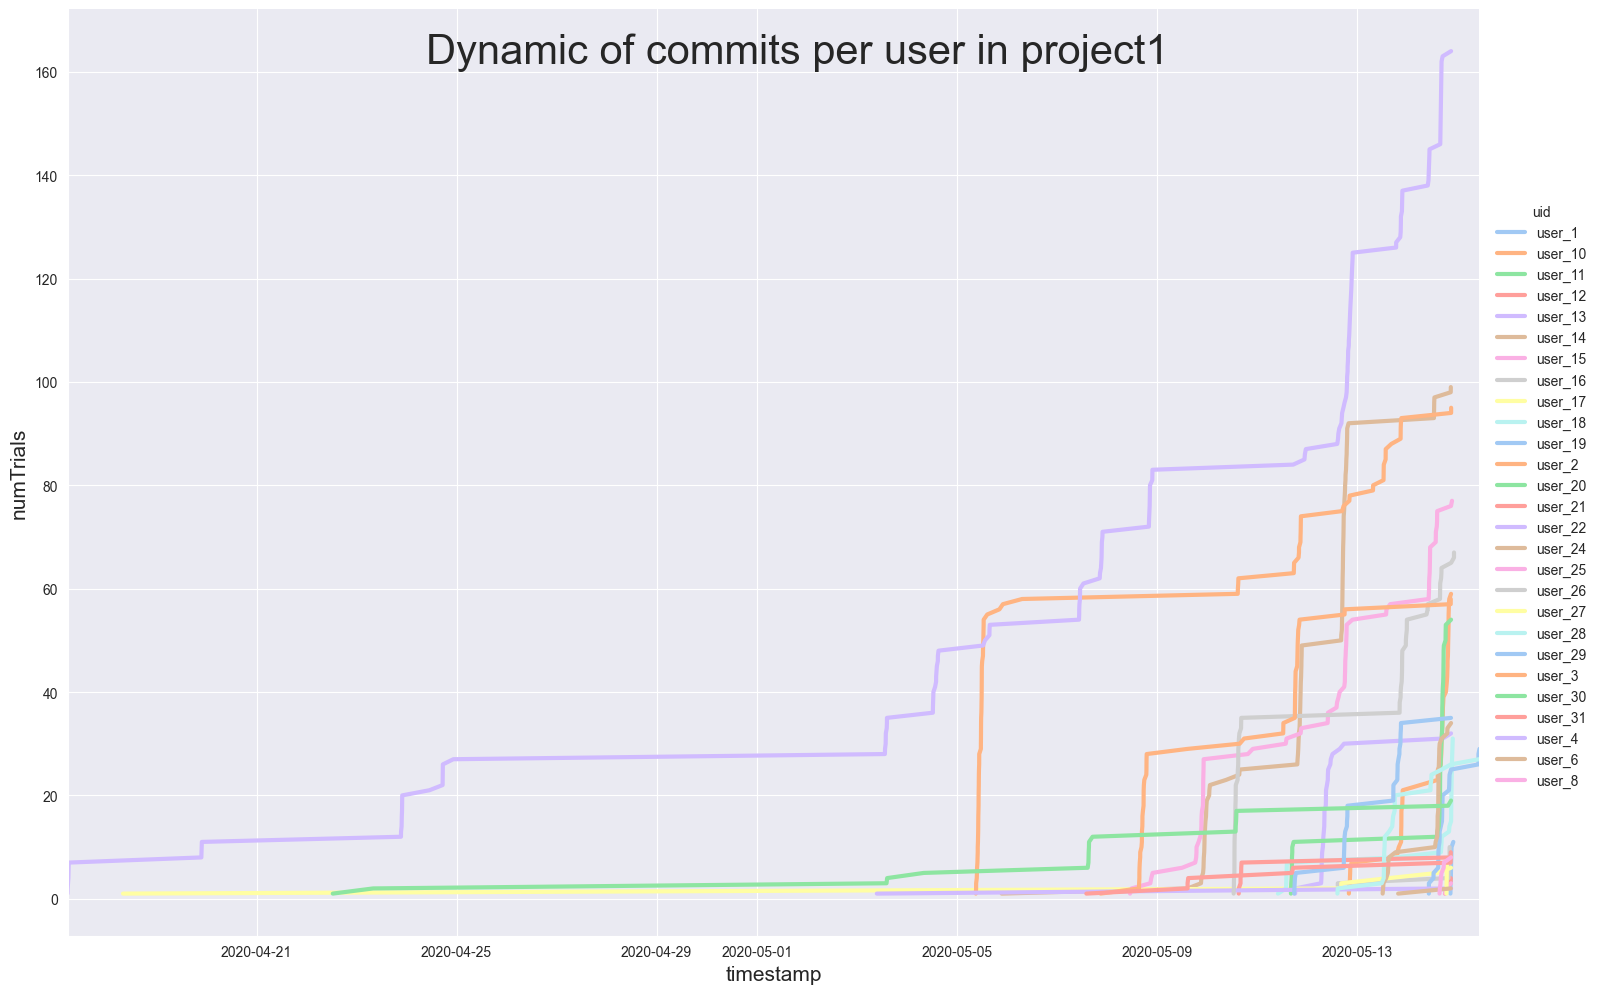

In [21]:
sns.set_style('darkgrid')
graph = sns.relplot(data=df, 
                   x="timestamp", 
                   y="numTrials", 
                   hue="uid", 
                   kind="line", linewidth=3, height=10, aspect=1.5, palette='pastel')
graph.ax.set_xlim([df["timestamp"].min(), df["timestamp"].max()])
graph.ax.xaxis.label.set_size(15)
graph.ax.yaxis.label.set_size(15)

graph.ax.set_title("Dynamic of commits per user in project1", fontsize=30, y=0.933, x=0.517)
plt.show()

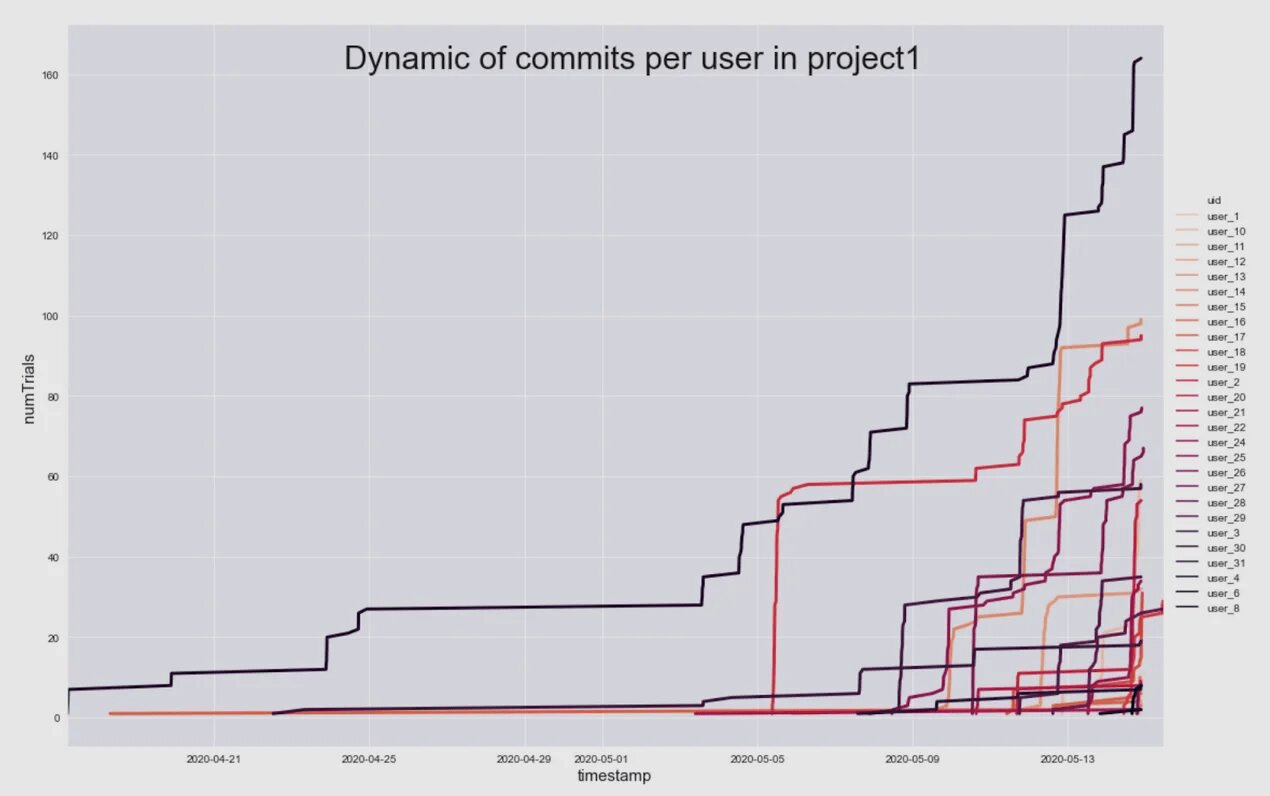

In [22]:
conn.close()

### “Which user was the leader in the number of commits almost all of the time?”

#### Answer is **user_4**

### “Which user was the leader for only a short period of time?”

#### Answer is **user_2**